# Modelagem — Predição de Alfabetização

## Pipeline Supervisionada de Machine Learning

**Objetivo:** Construir, treinar e validar um modelo supervisionado que estima a probabilidade de um aluno do 2º ano ser considerado alfabetizado, a partir do contexto escolar, territorial e socioeconômico.

**O que este notebook NÃO faz:**
- Análise exploratória (realizada em `01_eda.ipynb`, que fundamenta as decisões aqui aplicadas)
- Interpretabilidade por SHAP (responsabilidade de `03_interpretabilidade.ipynb`)
- Qualquer transformação fora da pipeline: imputação e encoding são etapas do estimador, nunca aplicadas à base antes da divisão

**O que este notebook entrega:**
1. Definição do universo, das features e do alvo
2. Divisão treino e teste agrupada por município
3. Pipeline de pré-processamento integrada ao modelo
4. Comparação entre modelo trivial, linear e de árvore
5. Otimização de hiperparâmetros com validação cruzada agrupada
6. Escolha do limiar de decisão segundo o custo do erro
7. Avaliação no conjunto de teste e persistência da pipeline treinada

## 1. Setup e Configuração

As listas de features consolidam as decisões da análise exploratória. Cada coluna excluída tem um motivo registrado: vazamento, variância zero, aleatoriedade por desenho amostral, redundância ou correlação nula com o alvo.

In [42]:
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    average_precision_score,
    balanced_accuracy_score,
    classification_report,
    f1_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import GroupKFold, GroupShuffleSplit, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

CAMINHO_BASE = "../data/base_gold_alunos.parquet"
CAMINHO_IMAGENS = "../images"
CAMINHO_MODELO = "../models/pipeline_alfabetizacao.joblib"
ANO_MODELAGEM = 2024
SEMENTE = 42
PROPORCAO_BUSCA = 0.4

ALVO = "alfabetizado"
AGRUPADOR = "id_municipio"

FEATURES_NUMERICAS = [
    "taxa_alfabetizacao_escola_historica",
    "alunos_avaliados_escola_historica",
    "taxa_alfabetizacao_municipio_historica",
    "idhm",
    "indice_gini",
    "taxa_criancas_dom_sem_fund",
    "taxa_atraso_0_fundamental",
    "diferenca_escola_municipio",
]
FEATURES_CATEGORICAS = ["sigla_uf", "rede_nome"]

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")

## 2. Universo, Engenharia de Atributos e Alvo

O universo replica a definição estabelecida na análise exploratória: alunos efetivamente avaliados no ano de 2024. O recorte temporal evita que o aluno seja descrito por um agregado que o contém.

### Atributo derivado

A taxa da escola e a do município medem contextos aninhados, e nenhuma das duas informa a posição relativa entre eles. Uma escola com 45% de alfabetização em um município de 40% está acima do próprio contexto; a mesma taxa em um município de 70% está bem abaixo. A diferença entre as duas expressa essa posição.

A derivação é linha a linha, sem agregação, e portanto não introduz vazamento ao ser calculada antes da divisão entre treino e teste.

In [43]:
base = pd.read_parquet(CAMINHO_BASE)

universo = base[
    (base["presenca"] == 1)
    & (base["preenchimento_caderno"] == 1)
    & (base["ano"] == ANO_MODELAGEM)
].copy()

universo["diferenca_escola_municipio"] = (
    universo["taxa_alfabetizacao_escola_historica"]
    - universo["taxa_alfabetizacao_municipio_historica"]
)

X = universo[FEATURES_NUMERICAS + FEATURES_CATEGORICAS]
y = universo[ALVO]
grupos = universo[AGRUPADOR]

print("=" * 60)
print("  UNIVERSO DE MODELAGEM")
print("=" * 60)
print(f"\nRegistros:    {len(X):>10,}")
print(f"Features:     {X.shape[1]:>10}")
print(f"Municípios:   {grupos.nunique():>10,}")
print(f"Taxa do alvo: {y.mean():>10.2%}")

  UNIVERSO DE MODELAGEM

Registros:     1,851,852
Features:             10
Municípios:        5,517
Taxa do alvo:     59.78%


## 3. Divisão Treino e Teste

A divisão é agrupada por município. Alunos do mesmo município compartilham todas as features contextuais, de modo que uma divisão aleatória colocaria registros praticamente idênticos nos dois lados e superestimaria a capacidade de generalização.

Agrupando, o conjunto de teste contém apenas municípios que o modelo nunca viu, que é a condição real de uso: estimar risco onde ainda não há medição.

In [44]:
divisor = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=SEMENTE)
indices_treino, indices_teste = next(divisor.split(X, y, groups=grupos))

X_treino, X_teste = X.iloc[indices_treino], X.iloc[indices_teste]
y_treino, y_teste = y.iloc[indices_treino], y.iloc[indices_teste]
grupos_treino, grupos_teste = grupos.iloc[indices_treino], grupos.iloc[indices_teste]

print("=" * 60)
print("  DIVISÃO AGRUPADA POR MUNICÍPIO")
print("=" * 60)
print(f"\nTreino:  {len(X_treino):>10,} alunos em {grupos_treino.nunique():>6,} municípios")
print(f"Teste:   {len(X_teste):>10,} alunos em {grupos_teste.nunique():>6,} municípios")
print(f"\nMunicípios em comum: {len(set(grupos_treino) & set(grupos_teste))}")
print(f"Taxa do alvo — treino: {y_treino.mean():.2%} | teste: {y_teste.mean():.2%}")

  DIVISÃO AGRUPADA POR MUNICÍPIO

Treino:   1,521,016 alunos em  4,413 municípios
Teste:      330,836 alunos em  1,104 municípios

Municípios em comum: 0
Taxa do alvo — treino: 59.33% | teste: 61.88%


## 4. Pipeline de Pré-processamento

O pré-processamento é parte do estimador, não uma etapa anterior. Isso garante que a mediana usada na imputação e a média usada na padronização sejam calculadas apenas sobre a partição de treino de cada dobra, sem contaminação pelos dados de validação.

**Numéricas:** imputação pela mediana, robusta à assimetria das distribuições, seguida de padronização. A padronização é indiferente para modelos de árvore e necessária para a regressão logística.

**Categóricas:** codificação one-hot com `handle_unknown="ignore"`, para que uma unidade federativa ausente em uma dobra não interrompa a validação. A saída em `float32` reduz pela metade a memória da matriz codificada, o que importa com 1,8 milhão de registros.

In [45]:
preprocessador = ColumnTransformer(
    [
        (
            "numericas",
            Pipeline([("imputacao", SimpleImputer(strategy="median")), ("escala", StandardScaler())]),
            FEATURES_NUMERICAS,
        ),
        (
            "categoricas",
            OneHotEncoder(handle_unknown="ignore", sparse_output=False, dtype=np.float32),
            FEATURES_CATEGORICAS,
        ),
    ]
)

preprocessador

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numericas', ...), ('categoricas', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``

## 5. Modelos Candidatos

Três candidatos, em ordem crescente de capacidade.

**Trivial.** Prediz sempre a classe majoritária. Estabelece o piso: qualquer modelo precisa superá-lo para justificar sua existência.

**Regressão logística.** Linear, interpretável e rápida. Dado que a maior correlação individual com o alvo é 0,25, é um candidato competitivo, não apenas uma referência.

**Gradient boosting.** Captura relações não lineares e interações. A análise exploratória mostrou que o IDHM separa apenas o quintil inferior, uma relação em degrau que modelos lineares não representam.

### Sobre a escolha das métricas

Com 59,78% de uma classe, o F1 calculado sobre a classe positiva premia quem prevê sempre "alfabetizado": recall perfeito na classe majoritária infla a métrica. As métricas abaixo evitam esse efeito.

- **ROC-AUC** mede discriminação e independe do limiar.
- **Average precision** resume a curva de precisão e revocação, mais sensível à classe minoritária.
- **F1 macro** e **acurácia balanceada** dão o mesmo peso às duas classes.
- **Recall em risco** é o recall da classe "não alfabetizado", que é o alvo prático da intervenção.

In [46]:
def avaliar(nome: str, y_real, probabilidades, limiar: float = 0.5) -> dict:
    predicoes = (probabilidades >= limiar).astype(int)
    return {
        "modelo": nome,
        "roc_auc": roc_auc_score(y_real, probabilidades),
        "average_precision": average_precision_score(y_real, probabilidades),
        "f1_macro": f1_score(y_real, predicoes, average="macro"),
        "acuracia_balanceada": balanced_accuracy_score(y_real, predicoes),
        "recall_em_risco": recall_score(y_real, predicoes, pos_label=0),
    }


modelos = {
    "trivial": DummyClassifier(strategy="most_frequent"),
    "logistica": LogisticRegression(max_iter=1000, random_state=SEMENTE),
    "boosting": HistGradientBoostingClassifier(random_state=SEMENTE),
}

resultados = []

for nome, estimador in modelos.items():
    pipeline = Pipeline([("preprocessamento", preprocessador), ("modelo", estimador)])
    pipeline.fit(X_treino, y_treino)

    resultados.append(avaliar(nome, y_teste, pipeline.predict_proba(X_teste)[:, 1]))
    print(f"[OK] {nome}")

pd.DataFrame(resultados).set_index("modelo").round(4)

[OK] trivial
[OK] logistica
[OK] boosting


,roc_auc,average_precision,f1_macro,acuracia_balanceada,recall_em_risco
modelo,,,,,
trivial,0.5000,0.6188,0.3822,0.5000,0.0000
logistica,0.6523,0.7479,0.5684,0.5805,0.2764
boosting,0.6545,0.7496,0.5614,0.5761,0.2611


## 6. Otimização de Hiperparâmetros

A busca usa `GroupKFold`, mantendo o agrupamento por município também dentro da validação cruzada. Sem isso, a otimização selecionaria os parâmetros que melhor exploram a semelhança entre alunos do mesmo município.

Duas restrições práticas orientam a execução. A busca roda sobre uma amostra de municípios do conjunto de treino, porque a escolha de hiperparâmetros é estável o suficiente para não exigir a base inteira. E o paralelismo fica limitado, já que cada processo aloca sua própria cópia da matriz codificada: com `n_jobs=-1` a execução esgota a memória disponível.

O modelo final é treinado sobre todo o conjunto de treino, com a configuração vencedora.

In [47]:
municipios_treino = grupos_treino.unique()
amostra_municipios = pd.Series(municipios_treino).sample(
    frac=PROPORCAO_BUSCA, random_state=SEMENTE
)
mascara_busca = grupos_treino.isin(amostra_municipios).values

X_busca = X_treino[mascara_busca]
y_busca = y_treino[mascara_busca]
grupos_busca = grupos_treino[mascara_busca]

print(f"Amostra para busca: {len(X_busca):,} alunos em {grupos_busca.nunique():,} municípios")

Amostra para busca: 567,782 alunos em 1,765 municípios


In [48]:
ESPACO_BUSCA = {
    "modelo__max_depth": [4, 6, 8, None],
    "modelo__learning_rate": [0.05, 0.1, 0.2],
    "modelo__max_iter": [100, 200, 300],
    "modelo__min_samples_leaf": [20, 50, 100],
}

busca = RandomizedSearchCV(
    Pipeline([
        ("preprocessamento", preprocessador),
        ("modelo", HistGradientBoostingClassifier(random_state=SEMENTE)),
    ]),
    ESPACO_BUSCA,
    n_iter=8,
    cv=GroupKFold(n_splits=3),
    scoring="roc_auc",
    random_state=SEMENTE,
    n_jobs=2,
    verbose=1,
    error_score="raise",
)

busca.fit(X_busca, y_busca, groups=grupos_busca)

print("=" * 60)
print("  MELHOR CONFIGURAÇÃO")
print("=" * 60)
print(f"\nROC-AUC na validação cruzada: {busca.best_score_:.4f}")
for parametro, valor in busca.best_params_.items():
    print(f"  {parametro}: {valor}")

Fitting 3 folds for each of 8 candidates, totalling 24 fits
  MELHOR CONFIGURAÇÃO

ROC-AUC na validação cruzada: 0.6643
  modelo__min_samples_leaf: 50
  modelo__max_iter: 200
  modelo__max_depth: 4
  modelo__learning_rate: 0.05


In [49]:
pd.DataFrame(busca.cv_results_)[
    ["params", "mean_test_score", "std_test_score", "rank_test_score"]
].sort_values("rank_test_score").round(4)

,params,mean_test_score,std_test_score,rank_test_score
2,"{'modelo__min_samples_leaf': 50, 'modelo__max_...",0.6643,0.0010,1
1,"{'modelo__min_samples_leaf': 50, 'modelo__max_...",0.6636,0.0027,2
6,"{'modelo__min_samples_leaf': 20, 'modelo__max_...",0.6619,0.0036,3
7,"{'modelo__min_samples_leaf': 20, 'modelo__max_...",0.6618,0.0028,4
0,"{'modelo__min_samples_leaf': 100, 'modelo__max...",0.6597,0.0040,5
4,"{'modelo__min_samples_leaf': 100, 'modelo__max...",0.6590,0.0029,6
5,"{'modelo__min_samples_leaf': 50, 'modelo__max_...",0.6585,0.0029,7
3,"{'modelo__min_samples_leaf': 100, 'modelo__max...",0.6585,0.0032,8


In [50]:
modelo_final = Pipeline([
    ("preprocessamento", preprocessador),
    ("modelo", HistGradientBoostingClassifier(random_state=SEMENTE)),
])
modelo_final.set_params(**busca.best_params_)
modelo_final.fit(X_treino, y_treino)

probabilidades = modelo_final.predict_proba(X_teste)[:, 1]

print("Modelo final treinado sobre o conjunto de treino completo")

Modelo final treinado sobre o conjunto de treino completo


## 7. Escolha do Limiar de Decisão

O limiar padrão de 0,5 pressupõe que errar para mais e errar para menos custam o mesmo. Aqui não custam.

O modelo existe para apoiar priorização de política pública. Sinalizar como em risco uma criança que seria alfabetizada custa o desperdício de uma parcela de atenção. Deixar de sinalizar uma criança que não será alfabetizada custa a ausência de intervenção onde ela era necessária. O segundo erro é mais caro, o que desloca o limiar.

A tabela abaixo mostra o efeito do limiar sobre a revocação da classe em risco.

In [51]:
LIMIARES = [0.3, 0.4, 0.5, 0.55, 0.6, 0.65, 0.7, 0.8]

comparacao_limiar = pd.DataFrame(
    [avaliar(f"limiar {limiar}", y_teste, probabilidades, limiar) for limiar in LIMIARES]
).set_index("modelo")

print("=" * 60)
print("  EFEITO DO LIMIAR SOBRE A DETECÇÃO DE RISCO")
print("=" * 60)
print()
print(comparacao_limiar.round(4).to_string())

  EFEITO DO LIMIAR SOBRE A DETECÇÃO DE RISCO

             roc_auc  average_precision  f1_macro  acuracia_balanceada  recall_em_risco
modelo                                                                                 
limiar 0.3    0.6546             0.7494    0.3931               0.5040           0.0107
limiar 0.4    0.6546             0.7494    0.4706               0.5346           0.0993
limiar 0.5    0.6546             0.7494    0.5649               0.5782           0.2689
limiar 0.55   0.6546             0.7494    0.6021               0.6006           0.4259
limiar 0.6    0.6546             0.7494    0.5862               0.6051           0.6749
limiar 0.65   0.6546             0.7494    0.5661               0.6032           0.7594
limiar 0.7    0.6546             0.7494    0.5176               0.5868           0.8481
limiar 0.8    0.6546             0.7494    0.3680               0.5357           0.9778


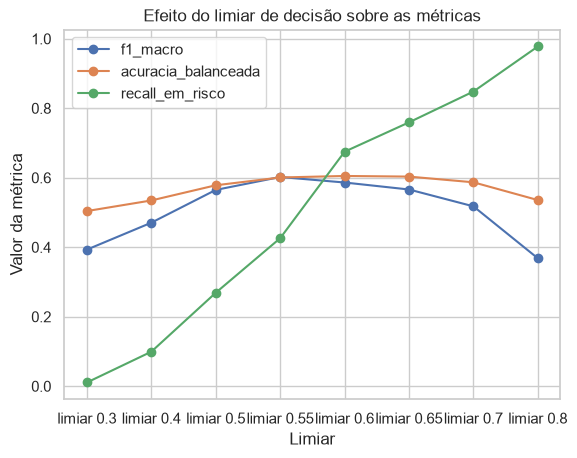

In [52]:
eixo = comparacao_limiar[["f1_macro", "acuracia_balanceada", "recall_em_risco"]].plot(marker="o")
eixo.set_title("Efeito do limiar de decisão sobre as métricas")
eixo.set_xlabel("Limiar")
eixo.set_ylabel("Valor da métrica")
plt.savefig(f"{CAMINHO_IMAGENS}/analise_limiar.png", dpi=150, bbox_inches="tight")
plt.show()

In [53]:
LIMIAR_ESCOLHIDO = 0.60

predicoes = (probabilidades >= LIMIAR_ESCOLHIDO).astype(int)

print("=" * 60)
print(f"  DESEMPENHO NO TESTE COM LIMIAR {LIMIAR_ESCOLHIDO}")
print("=" * 60)
print(f"\nROC-AUC:              {roc_auc_score(y_teste, probabilidades):.4f}")
print(f"Average precision:    {average_precision_score(y_teste, probabilidades):.4f}")
print(f"Acurácia balanceada:  {balanced_accuracy_score(y_teste, predicoes):.4f}")
print()
print(classification_report(y_teste, predicoes, target_names=["Não alfabetizado", "Alfabetizado"]))

  DESEMPENHO NO TESTE COM LIMIAR 0.6

ROC-AUC:              0.6546
Average precision:    0.7494
Acurácia balanceada:  0.6051

                  precision    recall  f1-score   support

Não alfabetizado       0.47      0.67      0.56    126128
    Alfabetizado       0.73      0.54      0.62    204708

        accuracy                           0.59    330836
       macro avg       0.60      0.61      0.59    330836
    weighted avg       0.63      0.59      0.59    330836



## 8. Avaliação no Conjunto de Teste

O conjunto de teste contém apenas municípios ausentes do treino e nunca foi usado em nenhuma decisão de modelagem.

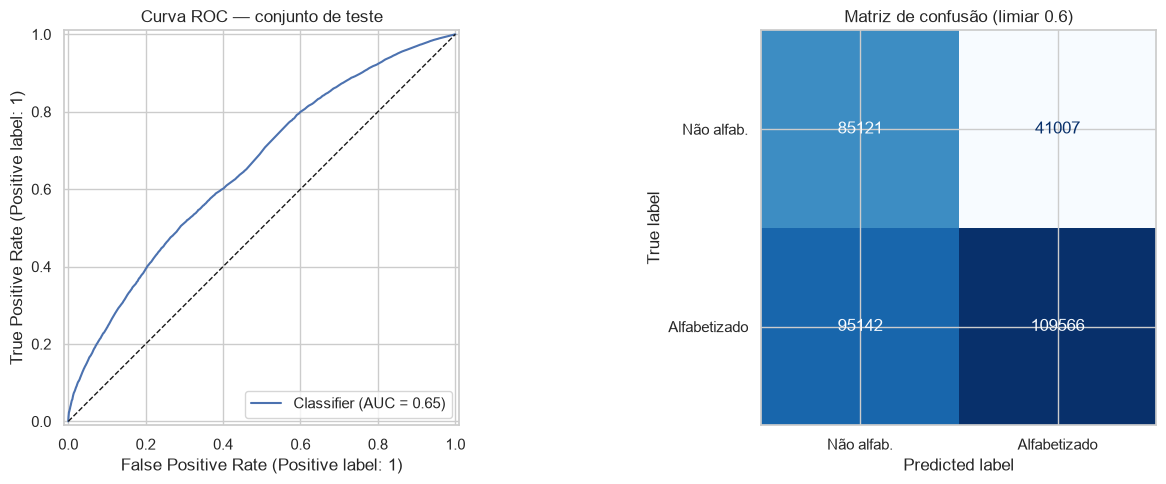

In [54]:
figura, (esquerda, direita) = plt.subplots(1, 2, figsize=(14, 5))

RocCurveDisplay.from_predictions(y_teste, probabilidades, ax=esquerda)
esquerda.plot([0, 1], [0, 1], "k--", linewidth=1)
esquerda.set_title("Curva ROC — conjunto de teste")

ConfusionMatrixDisplay.from_predictions(
    y_teste, predicoes, display_labels=["Não alfab.", "Alfabetizado"], cmap="Blues", ax=direita, colorbar=False
)
direita.set_title(f"Matriz de confusão (limiar {LIMIAR_ESCOLHIDO})")

plt.tight_layout()
plt.savefig(f"{CAMINHO_IMAGENS}/avaliacao_modelo.png", dpi=150, bbox_inches="tight")
plt.show()

### Distribuição das probabilidades previstas

Como todos os alunos de uma mesma escola e rede recebem features idênticas, as probabilidades previstas assumem poucos valores distintos. O gráfico torna essa característica visível e sustenta a leitura do resultado como score de risco territorial.

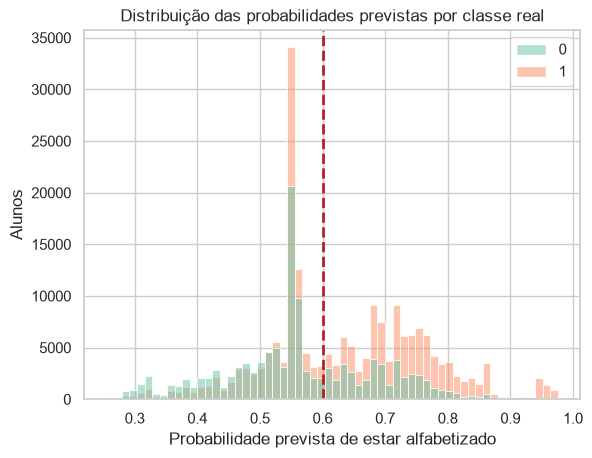

In [55]:
eixo = sns.histplot(x=probabilidades, hue=y_teste.values, bins=60, palette="Set2")
eixo.axvline(LIMIAR_ESCOLHIDO, color="firebrick", linestyle="--", linewidth=2)
eixo.set_title("Distribuição das probabilidades previstas por classe real")
eixo.set_xlabel("Probabilidade prevista de estar alfabetizado")
eixo.set_ylabel("Alunos")
plt.savefig(f"{CAMINHO_IMAGENS}/distribuicao_probabilidades.png", dpi=150, bbox_inches="tight")
plt.show()

## 9. Persistência da Pipeline

A pipeline serializada contém o pré-processamento e o modelo em um único objeto. É consumida por `03_interpretabilidade.ipynb`, evitando novo treinamento, e garante que qualquer predição futura aplique exatamente as mesmas transformações.

In [56]:
Path(CAMINHO_MODELO).parent.mkdir(exist_ok=True)
joblib.dump(modelo_final, CAMINHO_MODELO)

print(f"Pipeline salva em {CAMINHO_MODELO}")
print(f"Tamanho: {Path(CAMINHO_MODELO).stat().st_size / 1024**2:.1f} MB")

Pipeline salva em ../models/pipeline_alfabetizacao.joblib
Tamanho: 0.4 MB


## 10. Conclusões da Modelagem

| Aspecto | Resultado |
|---|---|
| Modelo escolhido | `HistGradientBoostingClassifier` com `max_depth=4`, `learning_rate=0.05`, `max_iter=200`, `min_samples_leaf=50` |
| ROC-AUC (validação cruzada) | 0,6643 |
| ROC-AUC (teste) | 0,6546 |
| Average precision (teste) | 0,7494 |
| Limiar adotado | 0,60, máximo empírico da acurácia balanceada |
| Acurácia balanceada | 0,6051 |
| Revocação da classe em risco | 0,6749, contra 0,2689 no limiar padrão |
| Precisão da classe em risco | 0,4722, contra taxa-base de 38,1% |
| Ganho sobre o modelo trivial | Acurácia balanceada de 0,5000 para 0,6051; revocação em risco de 0 para 0,6749 |
| Principal limitação | Ganho de 1,24 vez sobre o acaso na identificação de risco |

No conjunto de teste, o modelo identifica 85.121 das 126.128 crianças que não atingiram o nível de alfabetização.

### Leitura dos resultados

**A configuração vencedora é a mais regularizada do espaço de busca.** Árvore rasa e taxa de aprendizado baixa venceram configurações com maior capacidade. Com sinal fraco, capacidade adicional serve apenas para memorizar ruído, e a diferença de 0,0097 entre a validação cruzada e o teste confirma que não houve sobreajuste relevante.

**Gradient boosting e regressão logística empataram.** A diferença de 0,0022 em ROC-AUC é menor que o desvio padrão entre dobras da validação cruzada. A relação entre contexto territorial e alfabetização é essencialmente aditiva: não há interações que justifiquem um modelo mais complexo. O boosting foi mantido por permitir o uso de `TreeExplainer` na etapa de interpretabilidade, não por desempenho superior.

**O atributo derivado teve efeito marginal.** `diferenca_escola_municipio` expressa a posição da escola em relação ao próprio município. O ROC-AUC passou de 0,6548 para 0,6546, diferença dentro do ruído. No limiar de operação o ganho foi pequeno e consistente: a revocação da classe em risco subiu de 0,6673 para 0,6749, o equivalente a 958 crianças a mais identificadas. O atributo foi mantido e o resultado registrado como está.

**O limiar padrão inviabiliza o uso pretendido.** Em 0,50 o modelo identifica 27% das crianças em risco. O objetivo declarado é apoiar priorização de intervenção, e o custo de não sinalizar quem precisa supera o de sinalizar quem não precisa. Em 0,60 a revocação sobe para 67% com acurácia balanceada ligeiramente superior.

**As probabilidades previstas são discretas.** Como todos os alunos de uma mesma escola e rede recebem features idênticas, os scores se concentram em poucos valores. Há um agrupamento de aproximadamente 54 mil alunos em torno de 0,55, imediatamente abaixo do limiar adotado: entre 0,55 e 0,60 a revocação salta de 0,43 para 0,67. A escolha do limiar é mais consequente aqui do que seria com scores contínuos, e pequenas mudanças reclassificam dezenas de milhares de registros.

**O ganho é real e modesto.** Entre os alunos sinalizados como em risco, 47,2% de fato não se alfabetizaram, contra 38,1% que se obteria sinalizando ao acaso. É o que o dado permite sem nenhum atributo individual da criança.